In [1]:
import sys
sys.executable

'c:\\Users\\Abhi\\Documents\\hybrid-recommender\\mlops-hybrid-recommender-system\\.venv\\Scripts\\python.exe'

In [3]:
%pip install numpy pandas matplotlib

  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl (12.7 MB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install seaborn missingno

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ----------------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [10]:
DATA_DIR = Path("../data/raw/songs")

SONGS_PATH = DATA_DIR / "Music Info.csv"
HISTORY_PATH = DATA_DIR / "User Listening History.csv"

In [11]:
songs = pd.read_csv(SONGS_PATH)
listening_history = pd.read_csv(HISTORY_PATH)

print(f"Songs dataset: {songs.shape}")
print(f"Listening history: {listening_history.shape}")

Songs dataset: (50683, 21)
Listening history: (9711301, 3)


In [12]:
songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [13]:
listening_history.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


## 1. Song Dataset Overview

We first examine the structure, data types, and overall quality of the song metadata.

In [14]:
print(f"Number of songs: {songs.shape[0]:,}")
print(f"Number of features: {songs.shape[1]}")

songs.columns.tolist()

Number of songs: 50,683
Number of features: 21


['track_id',
 'name',
 'artist',
 'spotify_preview_url',
 'spotify_id',
 'tags',
 'genre',
 'year',
 'duration_ms',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

In [15]:
songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  str    
 1   name                 50683 non-null  str    
 2   artist               50683 non-null  str    
 3   spotify_preview_url  50683 non-null  str    
 4   spotify_id           50683 non-null  str    
 5   tags                 49556 non-null  str    
 6   genre                22348 non-null  str    
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null  float64
 1

In [16]:
missing_values = (
    songs.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

genre    28335
tags      1127
dtype: int64

In [17]:
missing_percentage = (
    songs.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

genre    55.906320
tags      2.223625
dtype: float64

In [18]:
print(f"Duplicate rows: {songs.duplicated().sum():,}")

Duplicate rows: 0


In [19]:
print(f"Unique track IDs: {songs['track_id'].nunique():,}")
print(f"Total rows: {len(songs):,}")

Unique track IDs: 50,683
Total rows: 50,683


### Initial Observations

- The dataset contains 50,683 rows and 21 features before cleaning.
- `track_id` is unique across all rows.
- Missing values occur only in `tags` and `genre`, with `genre` having substantially more missing data.
- No exact duplicate rows were found; however, song-level duplicates require further investigation using identifiers and song attributes.

In [20]:
songs.drop(columns=["spotify_preview_url"], inplace=True)

songs.head()

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


## 2. Duplicate Analysis

Song titles are not necessarily unique, as different artists can release tracks with the same name. Therefore, duplicates are examined using both song names and Spotify identifiers.

In [21]:
duplicate_names = (
    songs["name"]
    .str.lower()
    .duplicated()
    .sum()
)

print(f"Repeated song names: {duplicate_names:,}")

Repeated song names: 815


In [22]:
repeated_songs = songs[
    songs["name"].str.lower().duplicated(keep=False)
].copy()

repeated_songs["name_lower"] = repeated_songs["name"].str.lower()

repeated_songs.sort_values("name_lower")[
    ["name", "artist", "spotify_id", "year", "duration_ms"]
].head(20)

,name,artist,spotify_id,year,duration_ms
34480,3 am,Liv Kristine,1TgsnkiolcBhQssCR37JXx,2005,302880
6588,3 AM,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,1996,225946
29795,3AM,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,1996,225946
43800,3am,Halsey,1OfLNb6dQ9dra1B58iT9Ex,2020,234858
15088,4th of July,Soundgarden,237oH9rNUYpIBeHfAn3WJ0,1994,308866
38764,4th Of July,Aimee Mann,2fW1zQeo6QEhZviaudZvBu,2004,209173
418,A Day in the Life,The Beatles,10Qr2Dh7lz7Y5nK7K8yl9x,2014,303000
9974,A Day In The Life,Wes Montgomery,0GxCysYaqNYs57mP7vFaBR,2009,350333
32601,A Place In The Sun,Stevie Wonder,0cBiAr4rHiqs99k4kh7FZw,1985,171266
46102,A Place in the Sun,Lit,10vZsPb0c1gcNRoxP7dGKB,1999,260360


In [23]:
spotify_duplicates = songs.duplicated(subset="spotify_id").sum()

print(f"Duplicate Spotify IDs: {spotify_duplicates:,}")

Duplicate Spotify IDs: 9


In [24]:
duplicate_songs = songs.duplicated(
    subset=["spotify_id", "year", "duration_ms"]
).sum()

print(f"Duplicate song records: {duplicate_songs:,}")

Duplicate song records: 9


In [25]:
songs[
    songs.duplicated(
        subset=["spotify_id", "year", "duration_ms"],
        keep=False
    )
].sort_values(["spotify_id", "year", "duration_ms"])

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
15326,TRJNHPN128F92EF139,Adagio For Strings,Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,"instrumental, classical, soundtrack, beautiful",NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
21570,TRLSRQD128F426CFF8,"Adagio for Strings, Op. 11",Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,classical,NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
14861,TRLOZQZ128F92E8A3F,How Do You Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop",NaN,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
14981,TRXHJQY128F42B5094,How Do U Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop, american",Rap,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
37040,TRGCZFO128F92EE221,Je pense à toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,"alternative, beautiful, french",NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
49162,TRZBNQU128F148C04F,Je Pense A Toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,NaN,NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
13427,TRJQFIT128E0781CED,Too Much Too Young,The Specials,0ndKJL8gA4zLl317M7vndn,"punk, 80s, new_wave, reggae, ska",NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
46512,TRDTUTO128F422F138,Too Much Too Young (Live),The Specials,0ndKJL8gA4zLl317M7vndn,ska,NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
1684,TRRZUGN128F42A1EEE,There There,Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",Rock,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4
2983,TRXFHCL128F92E0989,"There, There",Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",NaN,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4


In [26]:
songs.drop_duplicates(
    subset=["spotify_id", "year", "duration_ms"],
    inplace=True
)

songs.reset_index(drop=True, inplace=True)

print(f"Dataset shape after removing duplicates: {songs.shape}")

Dataset shape after removing duplicates: (50674, 20)


## 3. Categorical Feature Analysis

The categorical features are examined to understand the diversity of songs, artists, genres, and descriptive tags in the catalogue.

In [38]:
categorical_columns = songs.select_dtypes(include="str").columns

categorical_columns.tolist()

['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre']

In [28]:
category_summary = pd.DataFrame({
    "unique_values": songs[categorical_columns].nunique(),
    "missing_values": songs[categorical_columns].isna().sum()
})

category_summary

,unique_values,missing_values
track_id,50674,0
name,50674,0
artist,8317,0
spotify_id,50674,0
tags,20054,1126
genre,15,28327


In [29]:
top_artists = songs["artist"].value_counts().head(15)

top_artists

artist
The Rolling Stones    132
Radiohead             110
Autechre              105
Tom Waits             100
Bob Dylan              98
The Cure               94
Metallica              85
Johnny Cash            84
Nine Inch Nails        83
Sonic Youth            81
Iron Maiden            76
Elliott Smith          76
In Flames              76
Boards of Canada       75
Mogwai                 75
Name: count, dtype: int64

In [30]:
genre_counts = songs["genre"].value_counts()

genre_counts

genre
Rock          9965
Electronic    3710
Metal         2516
Pop           1145
Rap            820
Jazz           793
RnB            696
Reggae         691
Country        607
Punk           383
Folk           355
New Age        237
Blues          189
World          140
Latin          100
Name: count, dtype: int64

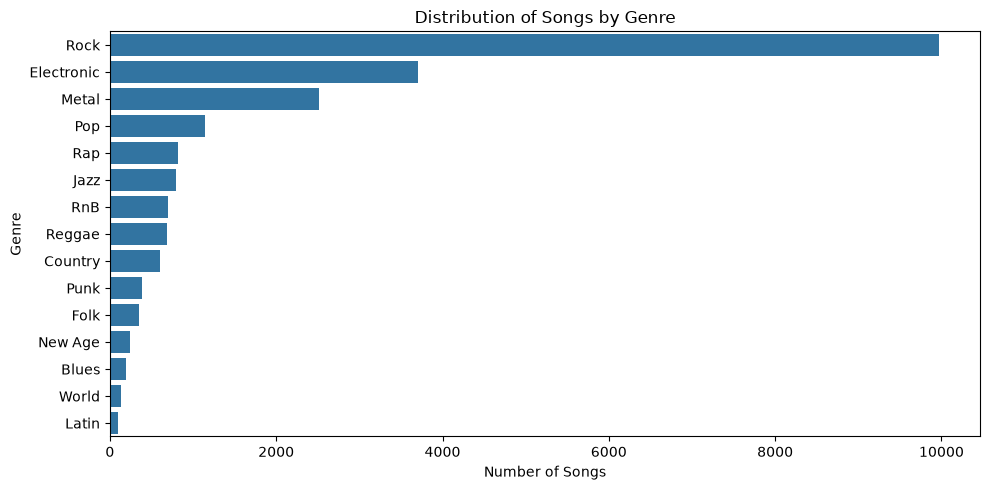

In [31]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=songs,
    y="genre",
    order=songs["genre"].value_counts().index
)

plt.title("Distribution of Songs by Genre")
plt.xlabel("Number of Songs")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

In [32]:
genre_samples = (
    songs.dropna(subset=["genre"])
    .groupby("genre", group_keys=False)
    .sample(n=3, random_state=42)
)

genre_samples[["name", "artist", "genre", "tags"]]

,name,artist,genre,tags
46194,El Viejo,La Vela Puerca,Blues,ska
42340,Hobo Train,Keri Leigh,Blues,"blues, blues_rock"
5059,The Things That I Used To Do,G. Love & Special Sauce,Blues,"alternative, jazz, blues, hip_hop, funk, male_..."
46742,Snake Eyes,The Alan Parsons Project,Country,"rock, classic_rock, progressive_rock"
44378,Take It So Hard,Keith Richards,Country,"rock, classic_rock, blues_rock"
30424,A Pirate Looks At Forty,Jimmy Buffett,Country,"folk, singer_songwriter, reggae, country"
2768,Sound of Silver,LCD Soundsystem,Electronic,"electronic, indie, punk, indie_rock, dance, el..."
39054,Outh9X,Autechre,Electronic,"electronic, ambient, experimental, idm"
20516,All There Is,Rites of Spring,Electronic,"punk, hardcore, post_punk, emo, post_hardcore"
10582,Fall on Me,R.E.M.,Folk,"rock, alternative, alternative_rock, classic_r..."


In [33]:
songs[["name", "artist", "genre", "tags"]].head(10)

,name,artist,genre,tags
0,Mr. Brightside,The Killers,NaN,"rock, alternative, indie, alternative_rock, in..."
1,Wonderwall,Oasis,NaN,"rock, alternative, indie, pop, alternative_roc..."
2,Come as You Are,Nirvana,RnB,"rock, alternative, alternative_rock, 90s, grunge"
3,Take Me Out,Franz Ferdinand,NaN,"rock, alternative, indie, alternative_rock, in..."
4,Creep,Radiohead,RnB,"rock, alternative, indie, alternative_rock, in..."
5,Somebody Told Me,The Killers,NaN,"rock, alternative, indie, pop, alternative_roc..."
6,Viva la Vida,Coldplay,NaN,"rock, alternative, indie, pop, alternative_roc..."
7,Karma Police,Radiohead,NaN,"rock, alternative, indie, alternative_rock, in..."
8,The Scientist,Coldplay,Rock,"rock, alternative, indie, pop, alternative_roc..."
9,Clocks,Coldplay,NaN,"rock, alternative, indie, pop, alternative_roc..."


In [34]:
all_tags = (
    songs["tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

print(f"Number of unique tags: {all_tags.nunique():,}")

Number of unique tags: 100


In [35]:
top_tags = all_tags.value_counts().head(20)

top_tags

tags
rock                 10681
indie                 7284
electronic            6592
alternative           6271
pop                   4650
female_vocalists      4515
alternative_rock      4134
indie_rock            3800
metal                 3181
classic_rock          2778
singer_songwriter     2747
experimental          2677
chillout              2655
ambient               2561
folk                  2530
punk                  2501
british               2409
instrumental          2353
hard_rock             2339
80s                   2307
Name: count, dtype: int64

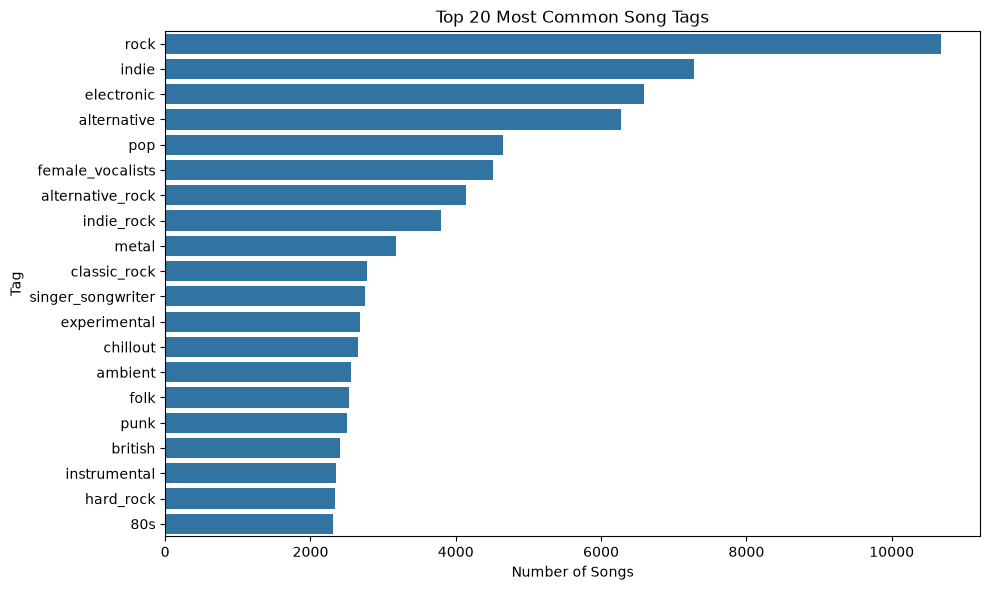

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_tags.values,
    y=top_tags.index
)

plt.title("Top 20 Most Common Song Tags")
plt.xlabel("Number of Songs")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

In [37]:
set(all_tags)

{'00s',
 '60s',
 '70s',
 '80s',
 '90s',
 'acoustic',
 'alternative',
 'alternative_rock',
 'ambient',
 'american',
 'avant_garde',
 'beautiful',
 'black_metal',
 'blues',
 'blues_rock',
 'british',
 'britpop',
 'chill',
 'chillout',
 'classic_rock',
 'classical',
 'country',
 'cover',
 'dance',
 'dark_ambient',
 'death_metal',
 'doom_metal',
 'downtempo',
 'drum_and_bass',
 'electro',
 'electronic',
 'emo',
 'experimental',
 'female_vocalists',
 'folk',
 'french',
 'funk',
 'german',
 'gothic',
 'gothic_metal',
 'grindcore',
 'grunge',
 'guitar',
 'hard_rock',
 'hardcore',
 'heavy_metal',
 'hip_hop',
 'house',
 'idm',
 'indie',
 'indie_pop',
 'indie_rock',
 'industrial',
 'instrumental',
 'j_pop',
 'japanese',
 'jazz',
 'lounge',
 'love',
 'male_vocalists',
 'mellow',
 'melodic_death_metal',
 'metal',
 'metalcore',
 'new_age',
 'new_wave',
 'noise',
 'nu_metal',
 'oldies',
 'piano',
 'polish',
 'pop',
 'pop_rock',
 'post_hardcore',
 'post_punk',
 'post_rock',
 'power_metal',
 'progress

## 4. Discrete and Time-Based Features

The integer-valued features include the release year, track duration, musical key, mode, and time signature. These features are examined separately because some represent categories rather than continuous quantities.

In [39]:
integer_columns = songs.select_dtypes(include="integer").columns

integer_columns.tolist()

['year', 'duration_ms', 'key', 'mode', 'time_signature']

In [40]:
integer_summary = songs[integer_columns].agg(["min", "max"]).T

integer_summary

,min,max
year,1900,2022
duration_ms,1439,3816373
key,0,11
mode,0,1
time_signature,0,5


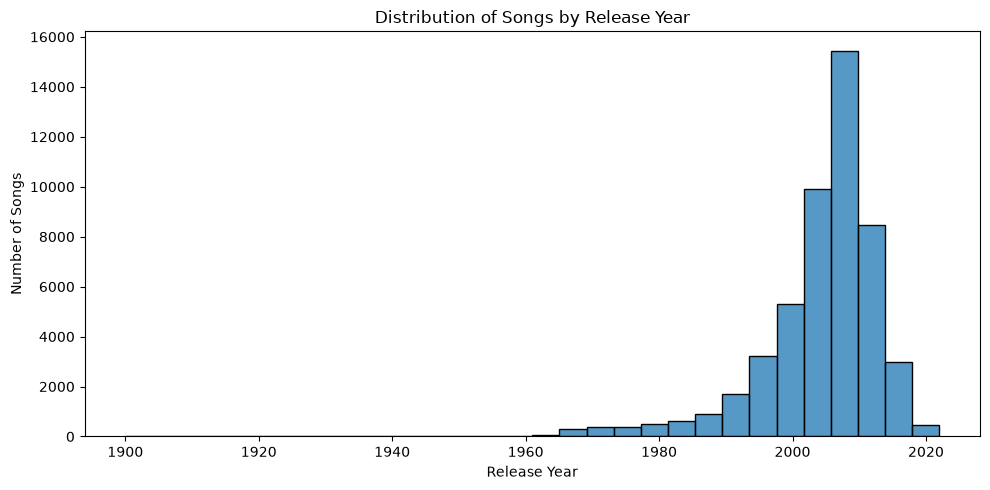

In [41]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=songs,
    x="year",
    bins=30
)

plt.title("Distribution of Songs by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

In [42]:
songs["year"].value_counts().head(10)

year
2007    4221
2008    3947
2009    3827
2006    3453
2005    3085
2010    2775
2004    2624
2003    2290
2011    2054
2002    1912
Name: count, dtype: int64

### Musical Key, Mode and Time Signature

`key`, `mode`, and `time_signature` are numerically encoded but represent musical categories:

- `key` represents the pitch class of the track (0–11).
- `mode` indicates major (1) or minor (0).
- `time_signature` represents the estimated number of beats in each measure.

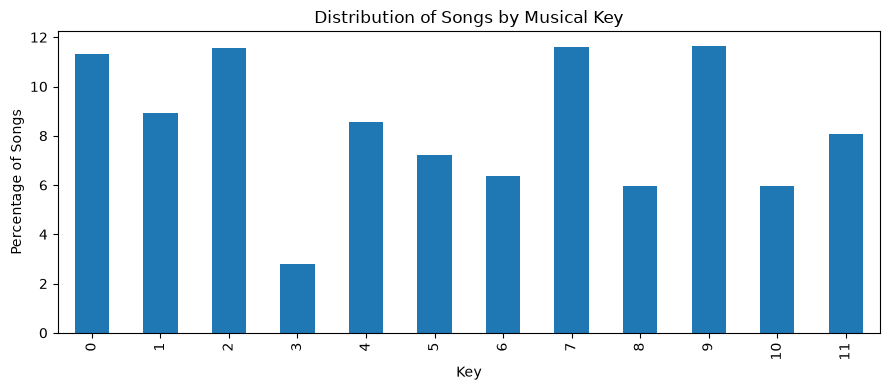

In [43]:
key_distribution = (
    songs["key"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

key_distribution.plot(kind="bar", figsize=(9, 4))

plt.title("Distribution of Songs by Musical Key")
plt.xlabel("Key")
plt.ylabel("Percentage of Songs")
plt.tight_layout()
plt.show()

In [44]:
mode_distribution = (
    songs["mode"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

mode_distribution

mode
0    36.892687
1    63.107313
Name: proportion, dtype: float64

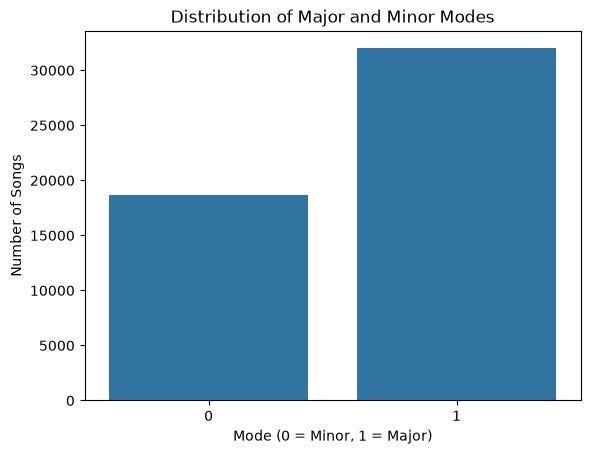

In [45]:
sns.countplot(data=songs, x="mode")

plt.title("Distribution of Major and Minor Modes")
plt.xlabel("Mode (0 = Minor, 1 = Major)")
plt.ylabel("Number of Songs")
plt.show()

In [46]:
time_signature_distribution = (
    songs["time_signature"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

time_signature_distribution

time_signature
0     0.019734
1     0.890003
3     8.880294
4    88.765442
5     1.444528
Name: proportion, dtype: float64

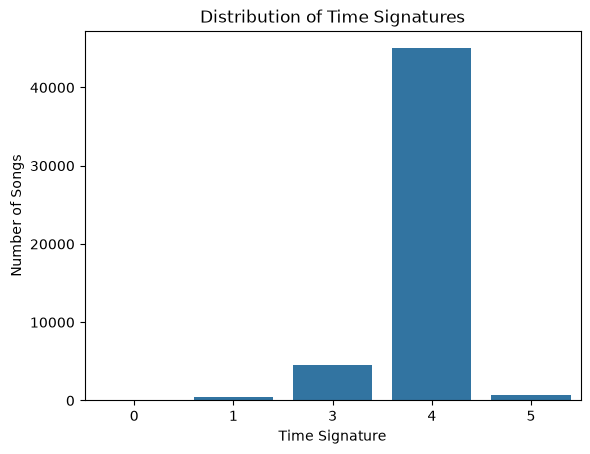

In [47]:
sns.countplot(
    data=songs,
    x="time_signature",
    order=sorted(songs["time_signature"].unique())
)

plt.title("Distribution of Time Signatures")
plt.xlabel("Time Signature")
plt.ylabel("Number of Songs")
plt.show()

In [48]:
duration_minutes = songs["duration_ms"] / 60000

duration_minutes.describe()

count    50674.000000
mean         4.185893
std          1.793154
min          0.023983
25%          3.212217
50%          3.915550
75%          4.803046
max         63.606217
Name: duration_ms, dtype: float64

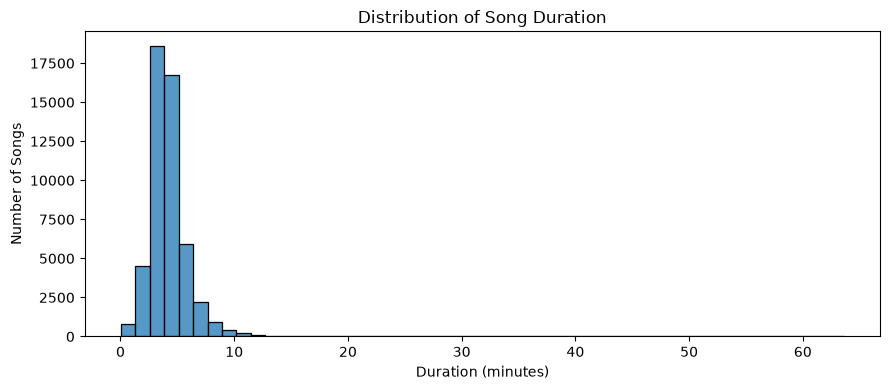

In [49]:
plt.figure(figsize=(9, 4))

sns.histplot(duration_minutes, bins=50)

plt.title("Distribution of Song Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

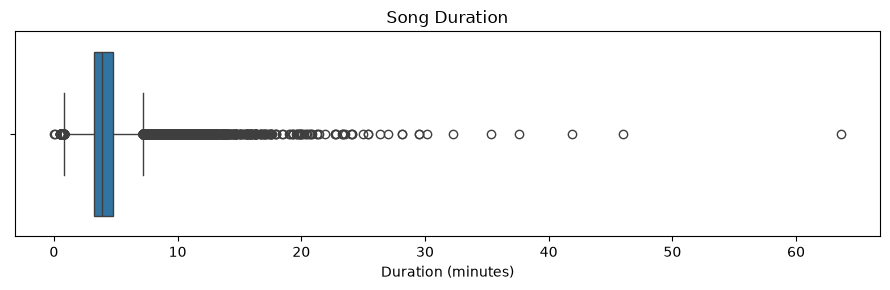

In [50]:
plt.figure(figsize=(9, 3))

sns.boxplot(x=duration_minutes)

plt.title("Song Duration")
plt.xlabel("Duration (minutes)")
plt.tight_layout()
plt.show()

In [51]:
songs.loc[
    duration_minutes > 60,
    ["name", "artist", "year", "duration_ms"]
]

,name,artist,year,duration_ms
25334,Dopesmoker,Sleep,2003,3816373


## 5. Audio Feature Analysis

The continuous audio features describe different characteristics of each track, including rhythm, intensity, acoustic properties, mood, and tempo.

In [52]:
continuous_columns = songs.select_dtypes(include="float").columns

continuous_columns.tolist()

['danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo']

In [53]:
songs[continuous_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,50674.0,0.493522,0.178833,0.0,0.364000,0.49700,0.62100,0.986
energy,50674.0,0.686507,0.251803,0.0,0.514000,0.74400,0.90500,1.000
loudness,50674.0,-8.291007,4.548359,-60.0,-10.375000,-7.19950,-5.08900,3.642
speechiness,50674.0,0.076026,0.076012,0.0,0.035200,0.04820,0.08350,0.954
acousticness,50674.0,0.213798,0.302839,0.0,0.001400,0.03990,0.34000,0.996
instrumentalness,50674.0,0.225299,0.337067,0.0,0.000018,0.00563,0.44100,0.999
liveness,50674.0,0.215439,0.184708,0.0,0.098400,0.13800,0.28900,0.999
valence,50674.0,0.433113,0.258767,0.0,0.214000,0.40500,0.63400,0.993
tempo,50674.0,123.508794,29.622349,0.0,100.682500,121.98900,141.64225,238.895


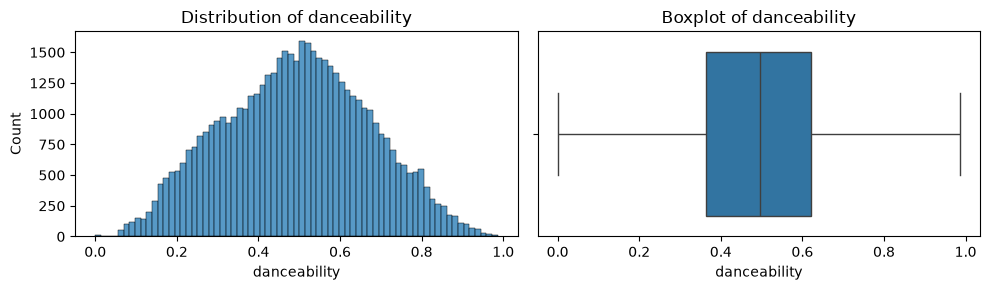

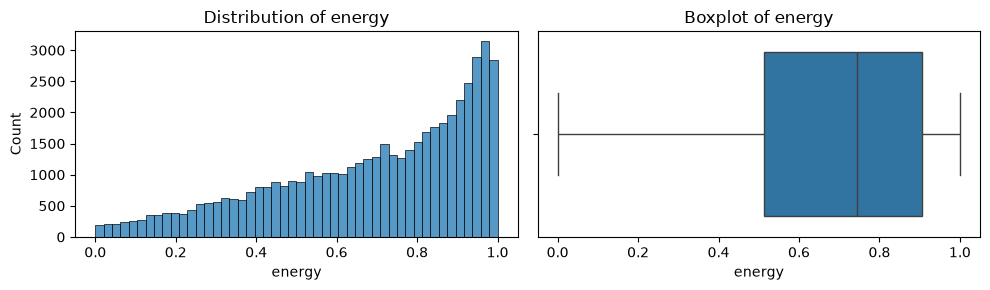

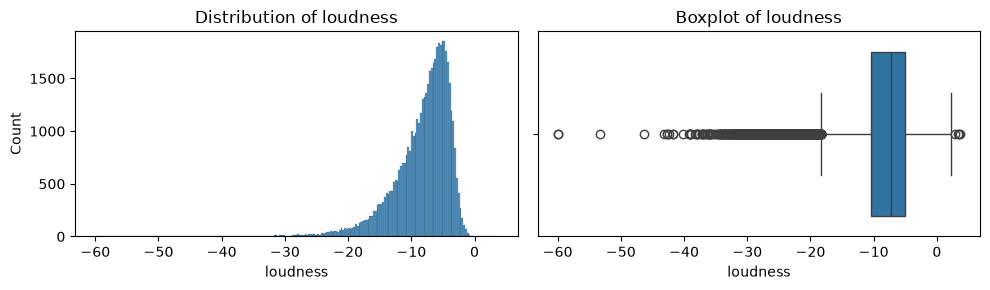

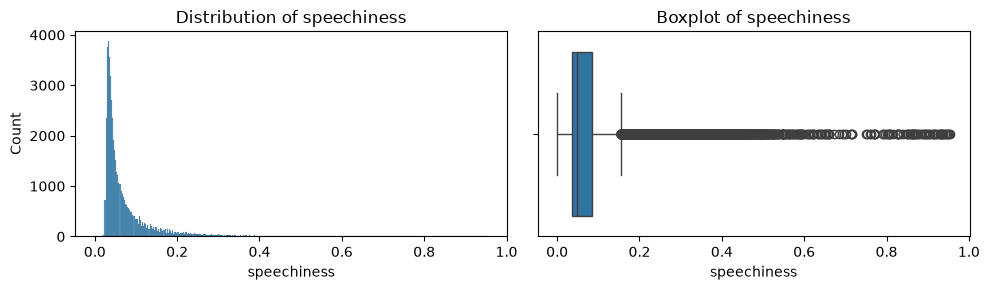

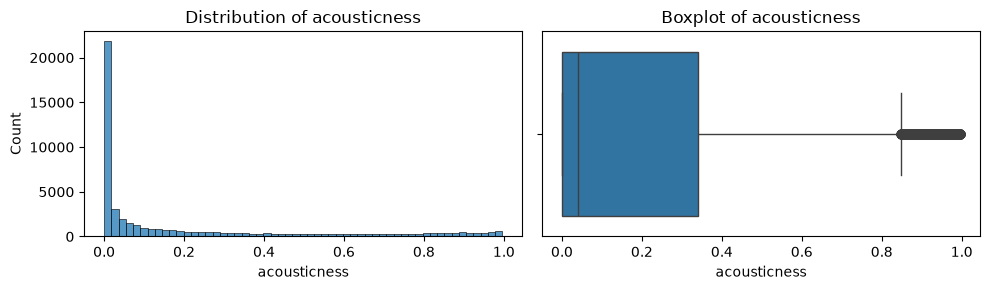

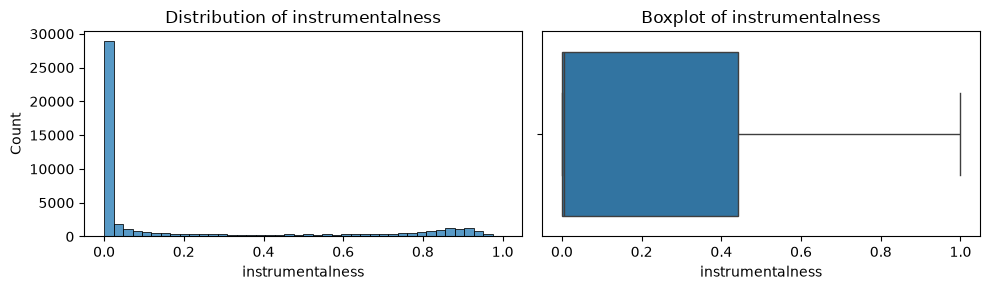

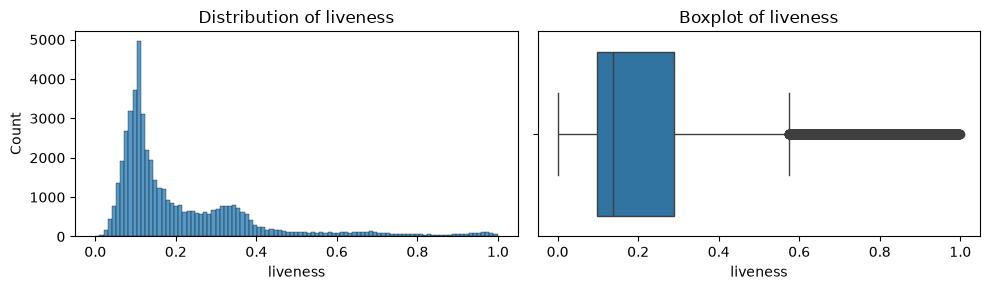

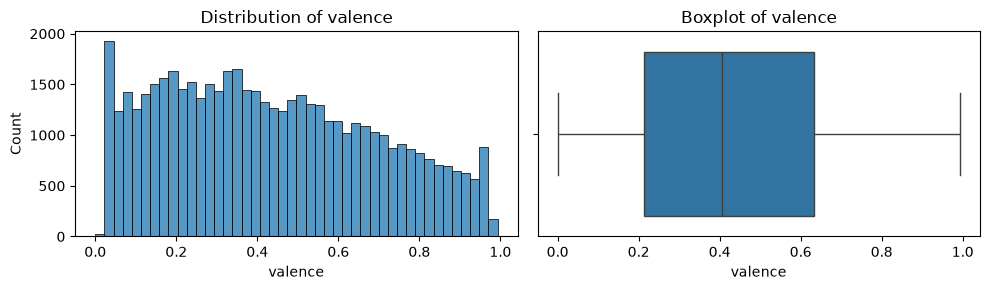

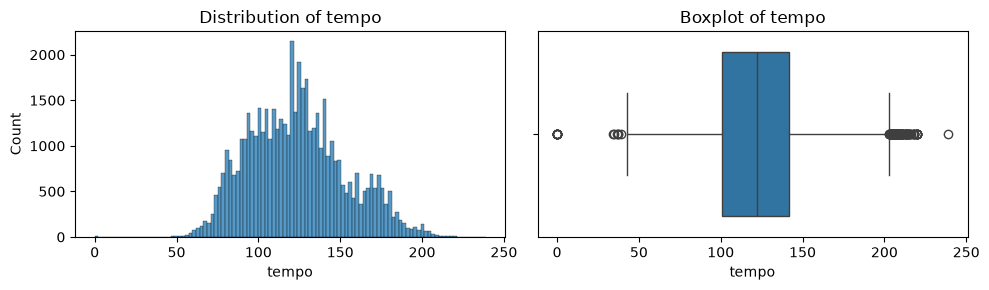

In [54]:
for column in continuous_columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    sns.histplot(data=songs, x=column, ax=axes[0])
    axes[0].set_title(f"Distribution of {column}")

    sns.boxplot(data=songs, x=column, ax=axes[1])
    axes[1].set_title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

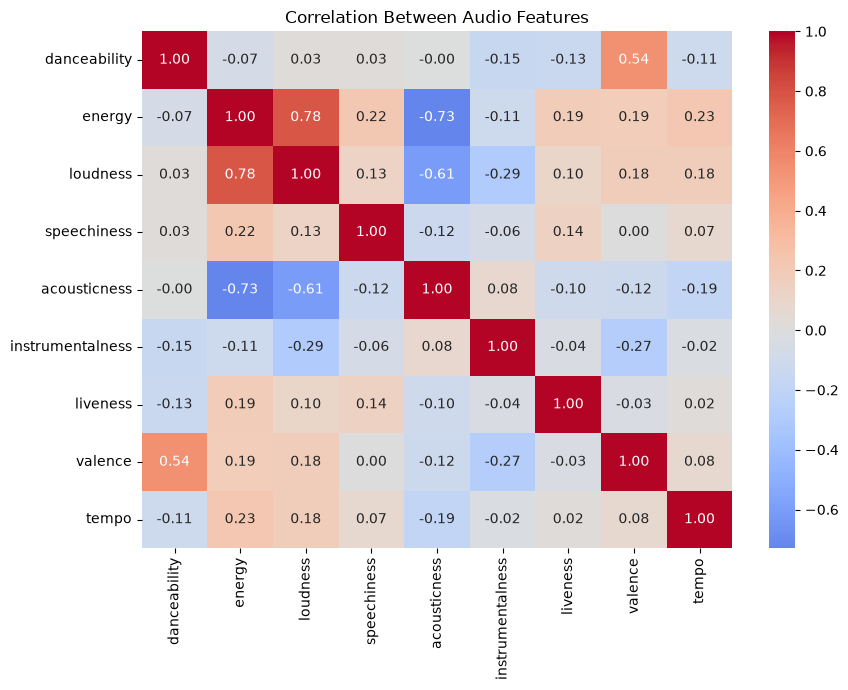

In [56]:
correlation_matrix = songs[continuous_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.show()

### Song Metadata Summary

- The catalogue contains over 50,000 unique tracks from more than 8,000 artists.
- Genre information is incomplete, while descriptive tags are available for most tracks and provide richer content information.
- Rock is the most represented genre, and the catalogue is not evenly distributed across genres.
- Track duration is concentrated around typical song lengths, with a small number of extreme-duration tracks.
- Audio features provide additional numerical descriptions of each track that can be used to measure similarity between songs.

## 6. User Listening History

The listening history contains user-song interactions represented by `user_id`, `track_id`, and `playcount`. This data will be used to understand listening behaviour and later support collaborative filtering.

In [57]:
listening_history.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [58]:
listening_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 9711301 entries, 0 to 9711300
Data columns (total 3 columns):
 #   Column     Dtype
---  ------     -----
 0   track_id   str  
 1   user_id    str  
 2   playcount  int64
dtypes: int64(1), str(2)
memory usage: 222.3 MB


In [59]:
print(f"Number of interactions: {len(listening_history):,}")
print(f"Number of features: {listening_history.shape[1]}")

Number of interactions: 9,711,301
Number of features: 3


In [60]:
listening_history.isna().sum()

track_id     0
user_id      0
playcount    0
dtype: int64

In [61]:
duplicate_interactions = listening_history.duplicated(
    subset=["track_id", "user_id"]
).sum()

print(f"Duplicate user-song interactions: {duplicate_interactions:,}")

Duplicate user-song interactions: 0


In [62]:
print(f"Unique users: {listening_history['user_id'].nunique():,}")
print(f"Unique songs: {listening_history['track_id'].nunique():,}")

Unique users: 962,037
Unique songs: 30,459


In [63]:
most_listened_songs = (
    listening_history["track_id"]
    .value_counts()
    .head(10)
)

most_listened_songs

track_id
TRONYHY128F92C9D11    80656
TRUFTBY128F93450B8    39529
TRXWAZC128F9314B3E    30873
TRCPXID128F92D5D3C    30057
TRGCHLH12903CB7352    29708
TROMKCG128F9320C09    28735
TRPFYYL128F92F7144    28412
TRPGPDK12903CCC651    27276
TRWAQOC12903CB84CA    27222
TRAALAH128E078234A    26689
Name: count, dtype: int64

In [64]:
most_listened_details = (
    most_listened_songs
    .rename("listener_count")
    .reset_index()
    .merge(
        songs[["track_id", "name", "artist"]],
        on="track_id",
        how="left"
    )
)

most_listened_details[
    ["name", "artist", "listener_count", "track_id"]
]

,name,artist,listener_count,track_id
0,Revelry,Kings of Leon,80656,TRONYHY128F92C9D11
1,Alejandro,Lady Gaga,39529,TRUFTBY128F93450B8
2,Heartbreak Warfare,John Mayer,30873,TRXWAZC128F9314B3E
3,Halo,Depeche Mode,30057,TRCPXID128F92D5D3C
4,Party In The U.S.A.,The Barden Bellas,29708,TRGCHLH12903CB7352
5,Uprising,Sabaton,28735,TROMKCG128F9320C09
6,Float On,Modest Mouse,28412,TRPFYYL128F92F7144
7,Bring Me To Life,Katherine Jenkins,27276,TRPGPDK12903CCC651
8,Sexy Bitch,David Guetta,27222,TRWAQOC12903CB84CA
9,Bitter Sweet Symphony,The Verve,26689,TRAALAH128E078234A


In [65]:
most_played_songs = (
    listening_history
    .groupby("track_id")["playcount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

most_played_songs

track_id
TRONYHY128F92C9D11    527893
TRUFTBY128F93450B8    111615
TRZNAHL128F9327D5A    111596
TRCPXID128F92D5D3C     91461
TRPGPDK12903CCC651     91448
TRXWAZC128F9314B3E     87745
TROMKCG128F9320C09     87050
TRPFYYL128F92F7144     85079
TRGCHLH12903CB7352     78443
TRAALAH128E078234A     76893
Name: playcount, dtype: int64

In [66]:
most_played_details = (
    most_played_songs
    .rename("total_playcount")
    .reset_index()
    .merge(
        songs[["track_id", "name", "artist"]],
        on="track_id",
        how="left"
    )
)

most_played_details[
    ["name", "artist", "total_playcount", "track_id"]
]

,name,artist,total_playcount,track_id
0,Revelry,Kings of Leon,527893,TRONYHY128F92C9D11
1,Alejandro,Lady Gaga,111615,TRUFTBY128F93450B8
2,Gears,Miss May I,111596,TRZNAHL128F9327D5A
3,Halo,Depeche Mode,91461,TRCPXID128F92D5D3C
4,Bring Me To Life,Katherine Jenkins,91448,TRPGPDK12903CCC651
5,Heartbreak Warfare,John Mayer,87745,TRXWAZC128F9314B3E
6,Uprising,Sabaton,87050,TROMKCG128F9320C09
7,Float On,Modest Mouse,85079,TRPFYYL128F92F7144
8,Party In The U.S.A.,The Barden Bellas,78443,TRGCHLH12903CB7352
9,Bitter Sweet Symphony,The Verve,76893,TRAALAH128E078234A


In [67]:
most_diverse_users = (
    listening_history
    .groupby("user_id")["track_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

most_diverse_users

user_id
ec6dfcf19485cb011e0b22637075037aae34cf26    784
4e11f45d732f4861772b2906f81a7d384552ad12    384
726da71c2c2ea119119a7957517fccd028d1be76    376
113255a012b2affeab62607563d03fbdf31b08e7    367
7adec7f006cb09482d36609d205293d8b61f030e    366
fef771ab021c200187a419f5e55311390f850a50    363
8cb51abc6bf8ea29341cb070fe1e1af5e4c3ffcc    362
b4c94d72b15d3c311c10045a58b31f95d9d12785    357
96f7b4f800cafef33eae71a6bc44f7139f63cd7a    356
6d625c6557df84b60d90426c0116138b617b9449    350
Name: track_id, dtype: int64

In [68]:
most_active_users = (
    listening_history
    .groupby("user_id")["playcount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

most_active_users

user_id
1854daf178674bbac9a8ed3d481f95b76676b414    2953
944cdf52364f45b0edd1c972b5a73d3a86b09c6a    2046
6a8a142084a4818c0dcac48bdfb3c39deacf5168    1942
93158e3983ffc8945e25c793d93d6b67d46cae9d    1845
f0b5c784daaa3c7d50acbb3723c7dd649db2b231    1841
6a58f480d522814c087fd3f8c77b3f32bb161f9d    1783
49127655d27dabab3f469bcdd996330fe4f3e210    1743
3fa44653315697f42410a30cb766a4eb102080bb    1639
839223f11c98e0c8017e8ecd6fc7b8706658c966    1608
af3ee32357049dd96231238bd1b019e8142ee6aa    1579
Name: playcount, dtype: int64

In [69]:
user_activity = pd.concat(
    [
        most_diverse_users.rename("unique_songs"),
        most_active_users.rename("total_playcount")
    ],
    axis=1
)

user_activity

,unique_songs,total_playcount
user_id,,
ec6dfcf19485cb011e0b22637075037aae34cf26,784.0,NaN
4e11f45d732f4861772b2906f81a7d384552ad12,384.0,NaN
726da71c2c2ea119119a7957517fccd028d1be76,376.0,NaN
113255a012b2affeab62607563d03fbdf31b08e7,367.0,NaN
7adec7f006cb09482d36609d205293d8b61f030e,366.0,NaN
fef771ab021c200187a419f5e55311390f850a50,363.0,NaN
8cb51abc6bf8ea29341cb070fe1e1af5e4c3ffcc,362.0,NaN
b4c94d72b15d3c311c10045a58b31f95d9d12785,357.0,NaN
96f7b4f800cafef33eae71a6bc44f7139f63cd7a,356.0,NaN


## 7. EDA Summary

The analysis highlights two complementary sources of information for building the recommendation system:

- **Song metadata** contains descriptive tags and audio characteristics that can be used to measure similarity between tracks for content-based recommendations.
- **Listening history** provides nearly 9.7 million user-song interactions across more than 962,000 users, providing behavioural information for collaborative filtering.
- Listening frequency varies substantially across songs and users, indicating differences in both song popularity and user activity.
- Song popularity can be measured in different ways: by the number of listeners or by total playcount.
- Combining item-level characteristics with user listening behaviour provides the basis for developing a hybrid recommendation system.
- The most diverse and most active users are different, suggesting that breadth of listening and overall listening intensity represent distinct user behaviours.